<a href="https://colab.research.google.com/github/jiyanshud22/TEMP/blob/main/Copy_of_CS496_UGP_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS496 UGP 1

*Jiyanshu Dhaka*
*(220481)*

*Ayan Bhardwaj*
*(220257)*


# Integer Linear Programming

to check if given number of red , green ,blue color cell can be arranged to fit within square grid with linear constraints.

R+G+B= (dimension)^2  

we can input custom linear constraints of form aR + bG + cB <= d.


from wikipedia, ILP cannonical form is :

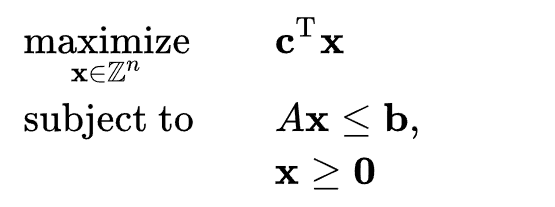

so, we use integer linear programming to check if it is possible to satisfy the constraint.

In [ ]:
from scipy.optimize import linprog

def can_fit_colors():
    """
    Check if the given [R, G, B] can fit into a square grid with constraints.

    Returns:
        str: 'YES' if the configuration is possible, otherwise 'NO'.
    """
    # Take inputs for the grid size and color counts
    grid_size = int(input("Enter the dimension of the square grid: "))
    R, G, B = map(int, input("Enter the counts of R, G, B (space-separated): ").replace(',', ' ').split())

    total_cells = grid_size ** 2

    # Ensure the total matches the grid size
    if R + G + B != total_cells:
        return "NO: The sum of R, G, and B does not equal the total grid cells."

    print("Define constraints:")
    print("1. Total cells constraint: R + G + B must equal total_cells.")
    print("2. Custom constraints must be of the form 'a b c d' for aR + bG + cB <= d.")

    custom_constraints = input("Do you want to add custom constraints? (yes/no): ").strip().lower()

    # Prepare the objective function (dummy since we're only checking feasibility)
    c = [0, 0, 0]  # Coefficients for R, G, B

    # Inequality constraints (Ax <= b)
    A_ub = []
    b_ub = []

    if custom_constraints == "yes":
        while True:
            constraint = input("Enter a custom constraint as 'a b c d' (or 'done' to finish): ").strip()
            if constraint.lower() == "done":
                break
            try:
                a, b, c_value, d = map(int, constraint.split())
                # Store coefficients in the correct order for the inequality
                A_ub.append([a, b, c_value])
                b_ub.append(d)
            except Exception as e:
                print(f"Error in constraint: {e}. Please enter in 'a b c d' format.")

    # Convert lists to numpy arrays if they're not empty
    A_ub = A_ub if A_ub else []  # Use an empty list if no constraints
    b_ub = b_ub if b_ub else []  # Use an empty list if no constraints

    # Variable bounds for R, G, B
    bounds = [(0, R), (0, G), (0, B)]

    # Equality constraint for total cells
    A_eq = [[1, 1, 1]]  # R + G + B = total_cells
    b_eq = [total_cells]

    try:
        # Solve the linear programming problem
        res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

        # Check if a feasible solution exists
        if res.success:
            return "YES"
        else:
            return "NO"
    except Exception as e:
        return f"An error occurred during linear programming: {e}"

# Example usage
if __name__ == "__main__":
    result = can_fit_colors()
    print(result)

Enter the dimension of the square grid: 10
Enter the counts of R, G, B (space-separated): 20 20 60
Define constraints:
1. Total cells constraint: R + G + B must equal total_cells.
2. Custom constraints must be of the form 'a b c d' for aR + bG + cB <= d.
Do you want to add custom constraints? (yes/no): yes
Enter a custom constraint as 'a b c d' (or 'done' to finish): 1 1 1 2000
Enter a custom constraint as 'a b c d' (or 'done' to finish): 3 4 5 100
Enter a custom constraint as 'a b c d' (or 'done' to finish): 3 3  3 1000
Enter a custom constraint as 'a b c d' (or 'done' to finish): done
NO


Now if constarint are not linear.

# Periphery constraint

if one colour does not have to be on periphery then it should satisfy:

R < = dimension*dimension - 4 * dimension + 4

if it has to be only on pheriphery then

R < = 4* dimension - 4

In [ ]:
import sys
import random

def fill_grid(rows, cols, red, green, blue, periphery_colors):
    # Initialize the grid with None
    grid = [[None] * cols for _ in range(rows)]
    color_counts = {'R': red, 'G': green, 'B': blue}

    # Define periphery positions
    periphery_positions = [(0, j) for j in range(cols)] + [(rows - 1, j) for j in range(cols)] + \
                          [(i, 0) for i in range(1, rows - 1)] + [(i, cols - 1) for i in range(1, rows - 1)]

    # Shuffle periphery positions to make selection random
    random.shuffle(periphery_positions)

    # Assign periphery colors in the order given by the user
    for color in periphery_colors:
        for i, j in periphery_positions:
            if grid[i][j] is None and color_counts[color] > 0:
                grid[i][j] = color
                color_counts[color] -= 1

    # Fill remaining periphery positions with available colors
    for i, j in periphery_positions:
        if grid[i][j] is None:
            for color in 'RGB':
                if color_counts[color] > 0:
                    grid[i][j] = color
                    color_counts[color] -= 1
                    break

    # Fill the remaining empty spaces in the grid
    for i in range(rows):
        for j in range(cols):
            if grid[i][j] is None:
                for color in 'RGB':
                    if color_counts[color] > 0:
                        grid[i][j] = color
                        color_counts[color] -= 1
                        break

    return grid

def main():
    # Get user input
    while True:
        rows = int(input("Enter the number of rows: "))
        cols = int(input("Enter the number of columns: "))
        red = int(input("Enter the number of red tiles: "))
        green = int(input("Enter the number of green tiles: "))
        blue = int(input("Enter the number of blue tiles: "))

        total_tiles = rows * cols
        if red + green + blue == total_tiles:
            break
        else:
            print(f"Invalid input! The total number of tiles ({red + green + blue}) must be equal to {total_tiles}.")
            sys.exit(1)

    while True:
        periphery_colors = input("Enter the colors for the periphery in order (R/G/B, e.g., R B G): ").strip().upper().split()
        if all(color in {'R', 'G', 'B'} for color in periphery_colors):
            break
        else:
            print("Invalid input! Please enter only R, G, or B for periphery colors.")
            sys.exit(1)

    # Call the function
    grid = fill_grid(rows, cols, red, green, blue, periphery_colors)

    # Print the grid if function is implemented
    if grid:
        for row in grid:
            print(" ".join(cell if cell is not None else '-' for cell in row))

if __name__ == "__main__":
    main()


Enter the number of rows: 8
Enter the number of columns: 8
Enter the number of red tiles: 20
Enter the number of green tiles: 18
Enter the number of blue tiles: 26
Enter the colors for the periphery in order (R/G/B, e.g., R B G): G B
G G G G B B G B
G R R R R R R G
G R R R R R R B
B R R R R R R G
G R R B B B B G
G B B B B B B G
B B B B B B B B
B G B G B G G G


# Diagonal Constraint:

if Red has to be only on daigonal then

R <= dimension

if Red cannot be on daigonal then

R <= dimension * dimension - dimension

In [ ]:
def fill_grid(dimension, red, green, blue, diagonal_colors):
    grid = [[None] * dimension for _ in range(dimension)]
    color_counts = {'R': red, 'G': green, 'B': blue}

    # Check if we have exactly the right number of colors to fill the grid
    total_cells = dimension * dimension
    total_colors = red + green + blue

    if total_colors != total_cells:
        return None  # Incorrect number of colors

    # Get all diagonal positions (both main diagonal and anti-diagonal)
    main_diagonal = [(i, i) for i in range(dimension)]
    anti_diagonal = [(i, dimension-1-i) for i in range(dimension)]

    # Remove duplicates (center cell in odd-sized grids)
    all_diagonal_positions = []
    for pos in main_diagonal + anti_diagonal:
        if pos not in all_diagonal_positions:
            all_diagonal_positions.append(pos)

    # First, try to fill all diagonal positions according to priority order
    for i, j in all_diagonal_positions:
        filled = False
        # Try each color in the priority list
        for priority_color in diagonal_colors:
            if color_counts[priority_color] > 0:
                grid[i][j] = priority_color
                color_counts[priority_color] -= 1
                filled = True
                break

        # If no priority color is available, try any color
        if not filled:
            for color in 'RGB':
                if color_counts[color] > 0:
                    grid[i][j] = color
                    color_counts[color] -= 1
                    filled = True
                    break

    # Then fill the rest of the grid
    for i in range(dimension):
        for j in range(dimension):
            if grid[i][j] is None:
                for color in 'RGB':
                    if color_counts[color] > 0:
                        grid[i][j] = color
                        color_counts[color] -= 1
                        break

    # Check if all cells are filled
    for i in range(dimension):
        for j in range(dimension):
            if grid[i][j] is None:
                return None  # Could not fill the entire grid

    return grid

# Example usage
def main():
    dimension = int(input("Enter the dimension: "))
    red = int(input("Enter the number of red tiles: "))
    green = int(input("Enter the number of green tiles: "))
    blue = int(input("Enter the number of blue tiles: "))
    diagonal_colors = input("Enter the colors for the diagonal in order (R/G/B, e.g., R G B): ").strip().upper().split()

    # Validate exact total colors
    total_cells = dimension * dimension
    total_colors = red + green + blue

    if total_colors != total_cells:
        print(f"Error: Incorrect number of colors. Need exactly {total_cells}, but have {total_colors}.")
        return

    grid = fill_grid(dimension, red, green, blue, diagonal_colors)

    if grid is None:
        print("Error: Could not fill the grid with the given colors.")
    else:
        for row in grid:
            print(" ".join(row))

if _name_ == "_main_":
    main()

NameError: name '_name_' is not defined

# **Adjacency Constraint:**
for R and G to be adjacent in grid: grid layout can be graph.

cells are nodes and adjacent cells share an edge.

let we define binary variable s.t. R[x]=0 if x cell does not contain red, else 1.


for each cell (i, j) in the grid:

If there is a red cell x[i, j]^R at position (i, j), then at least one of its adjacent cells must be green, represented as:
  - x[i, j+1]^G (right)
  - x[i, j-1]^G (left)
  - x[i-1, j]^G (above)
  - x[i+1, j]^G (below)

if x[i, j]^R ==1, then:  
x[i, j+1]^G + x[i, j-1]^G + x[i-1, j]^G + x[i+1, j]^G >= 1  

so wherever R is in a cell then atleast 1 G is near it and similarly if x[i, j]^G ==1, then:  
x[i, j+1]^R + x[i, j-1]^R + x[i-1, j]^R + x[i+1, j]^R >= 1  

so wherever G is in a cell then atleast 1 R is near it.



In [ ]:
import random

def get_user_input():
    n = int(input("Enter number of rows: "))
    m = int(input("Enter number of columns: "))
    total_cells = n * m

    tile_counts = {}
    tile_counts['R'] = int(input("Enter count of R: "))
    tile_counts['G'] = int(input("Enter count of G: "))
    tile_counts['B'] = int(input("Enter count of B: "))

    if sum(tile_counts.values()) != total_cells:
        print("Error: The sum of R, G, B must equal grid area.")
        return None, None, None

    adjacent_tiles = input("Enter two tiles for constraint (e.g., R G): ").split()
    if len(adjacent_tiles) != 2 or adjacent_tiles[0] not in tile_counts or adjacent_tiles[1] not in tile_counts or adjacent_tiles[0] == adjacent_tiles[1]:
        print("Error: Invalid tile constraint selection.")
        return None, None, None

    return n, m, tile_counts, adjacent_tiles

def generate_strategic_grid(n, m, tile_counts, adjacent_tiles):
    grid = [[' ' for _ in range(m)] for _ in range(n)]

    tile1, tile2 = adjacent_tiles[0], adjacent_tiles[1]
    if tile_counts[tile1] > tile_counts[tile2]:
        tile1, tile2 = tile2, tile1

    if tile_counts[tile2] > 4 * tile_counts[tile1]:
        print("Error: Not possible to satisfy the constraint.")
        return None, None, None

    placed_tiles = {'R': 0, 'G': 0, 'B': 0}
    adjacent_pairs = 0
    placed_positions = []

    row, col = 1, 1
    while placed_tiles[tile1] < tile_counts[tile1] and placed_tiles[tile2] < tile_counts[tile2]:
        if grid[row][col] == ' ':
            grid[row][col] = tile1
            placed_tiles[tile1] += 1
            placed_positions.append((row, col))

            adjacent_positions = [
                (row, col-1), (row, col+1),
                (row-1, col), (row+1, col)
            ]

            for adj_row, adj_col in adjacent_positions:
                if (0 <= adj_row < n and 0 <= adj_col < m and
                    grid[adj_row][adj_col] == ' ' and
                    placed_tiles[tile2] < tile_counts[tile2]):
                    grid[adj_row][adj_col] = tile2
                    placed_tiles[tile2] += 1
                    adjacent_pairs += 1

        col += 3
        if col >= m:
            col = 1
            row += 3
            if row >= n:
                break

    if placed_tiles[tile1] < tile_counts[tile1]:
        for i, j in placed_positions:
            diagonal_positions = [
                (i-1, j-1), (i-1, j+1),
                (i+1, j-1), (i+1, j+1)
            ]
            for di, dj in diagonal_positions:
                if (0 <= di < n and 0 <= dj < m and grid[di][dj] == ' ' and placed_tiles[tile1] < tile_counts[tile1]):
                    grid[di][dj] = tile1
                    placed_tiles[tile1] += 1
                    if placed_tiles[tile1] == tile_counts[tile1]:
                        break
            if placed_tiles[tile1] == tile_counts[tile1]:
                break

    if placed_tiles[tile2] < tile_counts[tile2]:
        for i, j in placed_positions:
            diagonal_positions = [
                (i-1, j-1), (i-1, j+1),
                (i+1, j-1), (i+1, j+1)
            ]
            for di, dj in diagonal_positions:
                if (0 <= di < n and 0 <= dj < m and grid[di][dj] == ' ' and placed_tiles[tile2] < tile_counts[tile2]):
                    grid[di][dj] = tile2
                    placed_tiles[tile2] += 1
                    if placed_tiles[tile2] == tile_counts[tile2]:
                        break
            if placed_tiles[tile2] == tile_counts[tile2]:
                break

    remaining_tiles = []
    for tile, count in tile_counts.items():
        remaining = count - placed_tiles[tile]
        remaining_tiles.extend([tile] * remaining)
    random.shuffle(remaining_tiles)

    for i in range(n):
        for j in range(m):
            if grid[i][j] == ' ' and remaining_tiles:
                grid[i][j] = remaining_tiles.pop()
                placed_tiles[grid[i][j]] += 1

    return grid, placed_tiles, adjacent_pairs

if __name__ == "__main__":
    n, m, tile_counts, adjacent_tiles = get_user_input()
    if n and m:
        grid, placed_tiles, adjacent_pairs = generate_strategic_grid(n, m, tile_counts, adjacent_tiles)
        if grid:
            for row in grid:
                print(" ".join(row))


Enter number of rows: 5
Enter number of columns: 5
Enter count of R: 10
Enter count of G: 7
Enter count of B: 8
Enter two tiles for constraint (e.g., R G): R G
G R G B R
R G R R G
G R G B R
B R B B B
R G R B B



# **No two adjacent tiles can have the same color.**

 Method:

 Start filling the grid from the top-left corner (0,0).
Try placing a color while checking if the rules are followed.
If a conflict occurs, undo the last step (backtrack) and try a different color.
Move to the next cell and repeat until the grid is completely filled.

R+G+B=n×m

C(i,j)
=C(i+1,j)
 and C(i,j)
 =C(i,j+1)

In [ ]:
import random

def generate_colored_grid(n, m, red_count, green_count, blue_count):
    """Generates a valid n x m grid with no two adjacent tiles having the same color."""
    def is_valid(grid, row, col, color, n, m):
        """Checks if placing the given color at (row, col) is valid."""
        directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # Up, Down, Left, Right

        for dr, dc in directions:
            r, c = row + dr, col + dc
            if 0 <= r < n and 0 <= c < m and grid[r][c] == color:
                return False  # Adjacent tile has the same color

        return True

    def solve(grid, row, col, color_counts, n, m):
        """Recursively fills the grid ensuring no two adjacent tiles have the same color."""
        if row == n:
            return True  # Successfully filled the entire grid

        next_row, next_col = (row, col + 1) if col + 1 < m else (row + 1, 0)

        for color in ['R', 'G', 'B']:
            if color_counts[color] > 0 and is_valid(grid, row, col, color, n, m):
                grid[row][col] = color  # Place color
                color_counts[color] -= 1

                if solve(grid, next_row, next_col, color_counts, n, m):
                    return True  # If valid solution found, return True

                grid[row][col] = None  # Backtrack
                color_counts[color] += 1

        return False  # No valid color found

    total_tiles = n * m
    if red_count + green_count + blue_count != total_tiles:
        print("Invalid input: Total number of tiles does not match grid size!")
        return None

    grid = [[None for _ in range(m)] for _ in range(n)]
    color_counts = {'R': red_count, 'G': green_count, 'B': blue_count}

    if not solve(grid, 0, 0, color_counts, n, m):
        print("No valid grid configuration found!")
        return None

    return grid


def print_grid(grid):
    """Prints the grid in a readable format."""
    for row in grid:
        print(" ".join(row))

# User Input
n = int(input("Enter the number of rows: "))
m = int(input("Enter the number of columns: "))
red_count = int(input("Enter the number of Red tiles: "))
green_count = int(input("Enter the number of Green tiles: "))
blue_count = int(input("Enter the number of Blue tiles: "))

# Generate and print the grid
grid = generate_colored_grid(n, m, red_count, green_count, blue_count)

if grid:
    print("\nGenerated Grid:")
    print_grid(grid)


Enter the number of rows: 7
Enter the number of columns: 5
Enter the number of Red tiles: 20
Enter the number of Green tiles: 13
Enter the number of Blue tiles: 10
Invalid input: Total number of tiles does not match grid size!


✔ No adjacency constraint – adjacent tiles can have the same color.

✔ User-defined block size – block_size × block_size (e.g., 3×3, 4×4).

✔ User-defined block color – only the selected color forms these blocks.

✔ User-defined tile counts – ensures correct distribution.

✔ Handles cases where blocks can't be placed – prints a warning.
# **Big Coloured Block Constraint**
 **Method:**
 R+G+B=n×m

 Choose a colour, Let us say blue

 Chose the dimensions of the block and number of blocks.

 Check if the possible arrangement is possible

 N* (S*S) <= B

 Tries 100 times per block to find space in the grid.

In [ ]:
import random

def place_blocks(grid, block_color, block_size, block_count, n, m, color_counts):
    """Places the required number of block_size × block_size blocks of a specific color in the grid."""
    required_tiles = block_count * (block_size ** 2)

    # Ensure we have enough tiles of the block color
    if required_tiles > color_counts[block_color]:
        print(f"Error: Not enough {block_color} tiles to form {block_count} blocks of size {block_size}×{block_size}.")
        return False  # Return False to indicate failure

    placed_blocks = 0
    for _ in range(block_count):
        found = False
        for _ in range(100):  # Try 100 random placements
            row = random.randint(0, n - block_size)
            col = random.randint(0, m - block_size)

            # Check if the block_size × block_size area is free
            if all(grid[r][c] is None for r in range(row, row + block_size) for c in range(col, col + block_size)):
                # Place the block
                for r in range(row, row + block_size):
                    for c in range(col, col + block_size):
                        grid[r][c] = block_color

                placed_blocks += 1
                color_counts[block_color] -= (block_size ** 2)  # Reduce available tiles
                found = True
                break  # Move to next block

        if not found:
            print(f"Warning: Could not place all {block_count} blocks.")
            return False  # Return False to indicate failure

    return True  # Blocks placed successfully

def fill_remaining_tiles(grid, color_counts, n, m):
    """Fills the remaining tiles randomly while ensuring total tile counts are met."""
    available_positions = [(r, c) for r in range(n) for c in range(m) if grid[r][c] is None]
    random.shuffle(available_positions)

    for color in ['R', 'G', 'B']:
        for _ in range(color_counts[color]):
            if available_positions:
                row, col = available_positions.pop()
                grid[row][col] = color

def generate_colored_grid(n, m, red_count, green_count, blue_count, block_color, block_size, block_count):
    """Generates a valid n × m grid with block_size × block_size blocks and fills remaining spaces randomly."""
    total_tiles = n * m
    if red_count + green_count + blue_count != total_tiles:
        print("Error: The total number of tiles must be equal to n × m.")
        return None  # Return None instead of exiting

    grid = [[None for _ in range(m)] for _ in range(n)]
    color_counts = {'R': red_count, 'G': green_count, 'B': blue_count}

    # Place blocks first
    if not place_blocks(grid, block_color, block_size, block_count, n, m, color_counts):
        return None  # Return None instead of exiting

    # Fill the rest randomly
    fill_remaining_tiles(grid, color_counts, n, m)

    return grid

def print_grid(grid):
    """Prints the grid in a readable format."""
    for row in grid:
        print(" ".join(row))

# User Input
n = int(input("Enter the number of rows: "))
m = int(input("Enter the number of columns: "))
red_count = int(input("Enter the number of Red tiles: "))
green_count = int(input("Enter the number of Green tiles: "))
blue_count = int(input("Enter the number of Blue tiles: "))

# **Exit immediately if the total number of tiles is incorrect**
if red_count + green_count + blue_count != n * m:
    print("Error: The total number of tiles must be equal to n × m.")
    exit()

block_color = input("Enter the color (R, G, B) for the blocks: ").strip().upper()
block_size = int(input("Enter the block size (e.g., 3 for 3×3 blocks): "))
block_count = int(input(f"Enter the number of {block_size}×{block_size} blocks for {block_color}: "))

# Generate and print the grid
grid = generate_colored_grid(n, m, red_count, green_count, blue_count, block_color, block_size, block_count)

if grid:
    print("\nGenerated Grid:")
    print_grid(grid)


Enter the number of rows: 5
Enter the number of columns: 5
Enter the number of Red tiles: 2
Enter the number of Green tiles: 2
Enter the number of Blue tiles: 21
Enter the color (R, G, B) for the blocks: B
Enter the block size (e.g., 3 for 3×3 blocks): 3
Enter the number of 3×3 blocks for B: 1

Generated Grid:
G B R B B
B B B G B
B B B B B
B R B B B
B B B B B


# **Pattern constraint**


In [ ]:
import random
import sys

def max_patterns(X, Y, Z, pattern):
    """Calculates the maximum number of patterns that can be formed based on available tiles."""
    # Count occurrences of R, G, B in the given pattern
    x = pattern.count('R')
    y = pattern.count('G')
    z = pattern.count('B')

    # Prevent division by zero (if color is absent in the pattern, set its count high)
    x = X // x if x > 0 else float('inf')
    y = Y // y if y > 0 else float('inf')
    z = Z // z if z > 0 else float('inf')

    # Compute max number of patterns that can be placed
    return min(x, y, z)

def fill_with_patterns(grid, pattern, pattern_length, color_counts, n, m, max_patterns):
    """Fills the grid row-wise using the user-specified pattern while ensuring tile counts are not exceeded."""
    row, applied_patterns = 0, 0

    while applied_patterns < max_patterns and row < n:
        for start_col in range(0, m, pattern_length):
            end_col = start_col + pattern_length

            # Ensure pattern fits within row
            if end_col > m:
                break  # Skip to next row

            pattern_slice = list(pattern[:end_col - start_col])

            # Check if we have enough tiles to place this pattern
            if all(color_counts[color] >= pattern_slice.count(color) for color in pattern_slice):
                grid[row][start_col:end_col] = pattern_slice
                for color in pattern_slice:
                    color_counts[color] -= 1  # Deduct used colors
                applied_patterns += 1  # Increment count of applied patterns

            if applied_patterns >= max_patterns:
                return  # Stop placing patterns once we reach max count

        # Always move to the next row
        row += 1

def fill_remaining(grid, color_counts, n, m):
    """Fills remaining empty cells randomly but ensuring total tile counts match exactly."""
    available_tiles = [color for color, count in color_counts.items() for _ in range(count)]
    random.shuffle(available_tiles)
    tile_index = 0

    for row in range(n):
        for col in range(m):
            if grid[row][col] is None and tile_index < len(available_tiles):
                grid[row][col] = available_tiles[tile_index]
                tile_index += 1

def generate_colored_grid(n, m, red_count, green_count, blue_count, pattern, pattern_length):
    """Generates an n × m grid using the specified tile pattern and fills remaining spaces randomly."""
    total_tiles = n * m
    given_tiles = red_count + green_count + blue_count

    if given_tiles != total_tiles:
        print("\n❌ Invalid Configuration: The total number of tiles does not match the grid size!")
        sys.exit(1)

    if pattern_length > m:
        print("\n❌ This configuration cannot be possible! The pattern length exceeds the number of columns.")
        sys.exit(1)

    if len(pattern) != pattern_length:
        print("\n❌ Invalid Pattern: The specified pattern length does not match the given pattern!")
        sys.exit(1)

    # Calculate max patterns that can be formed
    max_patterns_count = max_patterns(red_count, green_count, blue_count, pattern)
    print(f"\n✅ Maximum number of patterns that can be formed: {max_patterns_count}")  # Print before grid generation
    if(max_patterns_count==0):
       print("\n❌ This configuration cannot be possible!")
       sys.exit(1)
    grid = [[None for _ in range(m)] for _ in range(n)]
    color_counts = {'R': red_count, 'G': green_count, 'B': blue_count}

    fill_with_patterns(grid, pattern, pattern_length, color_counts, n, m, max_patterns_count)
    fill_remaining(grid, color_counts, n, m)

    return grid

def print_grid(grid):
    """Prints the grid in a readable format."""
    for row in grid:
        print(" ".join(row))

# User Input
n = int(input("Enter the number of rows: "))
m = int(input("Enter the number of columns: "))
red_count = int(input("Enter the number of Red tiles: "))
green_count = int(input("Enter the number of Green tiles: "))
blue_count = int(input("Enter the number of Blue tiles: "))

total_tiles = n * m
given_tiles = red_count + green_count + blue_count

if given_tiles != total_tiles:
    print("\n❌ Invalid Configuration: The total number of tiles does not match the grid size!")
    sys.exit(1)

pattern_length = int(input("Enter the number of tiles for the pattern: "))
pattern = input(f"Enter the pattern of {pattern_length} tiles (e.g., RRGB): ").strip().upper()

if pattern_length > m:
    print("\n❌ This configuration cannot be possible! The pattern length exceeds the number of columns.")
    sys.exit(1)

if len(pattern) != pattern_length:
    print("\n❌ Invalid Pattern: The specified pattern length does not match the given pattern!")
    sys.exit(1)

# Calculate and print the maximum number of patterns before generating the grid
max_patterns_count = max_patterns(red_count, green_count, blue_count, pattern)
grid = generate_colored_grid(n, m, red_count, green_count, blue_count, pattern, pattern_length)

if grid:
    print("\n✅ Generated Grid:")
    print_grid(grid)


Enter the number of rows: 5
Enter the number of columns: 5
Enter the number of Red tiles: 5
Enter the number of Green tiles: 10
Enter the number of Blue tiles: 10
Enter the number of tiles for the pattern: 3
Enter the pattern of 3 tiles (e.g., RRGB): RRG

✅ Maximum number of patterns that can be formed: 2

✅ Generated Grid:
R R G G G
R R G G G
B G G B R
B B B B B
G G B B B


# Weighted Positional Constraint

we defined weights in all 4 quadrants for all colours in case of even dimension

w_red_UL + w_red_UR + w_red_LL + w_red_LR = 1

and in case of odd dimension we also defined weights on axis and origin.

there were weights for neighbouring elements as well.


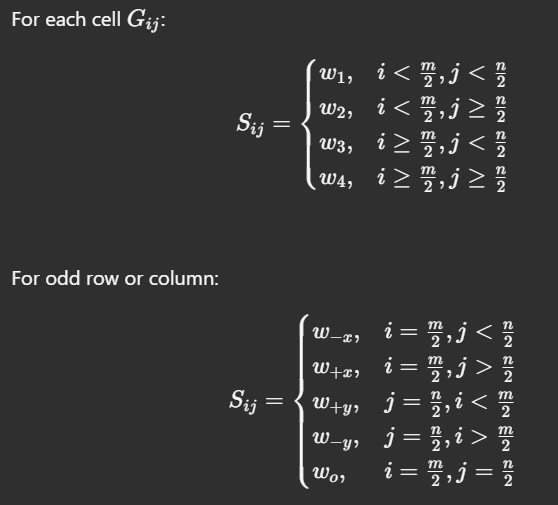

then we calculated maximum score. Sij is score of i,j position.

In [ ]:
import itertools
import random


def generate_empty_grid(rows, cols):
    return [['-' for _ in range(cols)] for _ in range(rows)]

def count_neighbors(grid, row, col, rows, cols):
    neighbors = {'R': 0, 'G': 0, 'B': 0}
    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nr, nc = row + dr, col + dc
        if 0 <= nr < rows and 0 <= nc < cols and grid[nr][nc] in neighbors:
            neighbors[grid[nr][nc]] += 1
    return neighbors


def fill_quadrant(grid, quadrant, color_counts, color_weights, adj_weights, rows, cols, score):
    quadrant_map = {
        'UL': (0, 0, rows // 2, cols // 2),
        'UR': (0, cols // 2, rows // 2, cols),
        'LL': (rows // 2, 0, rows, cols // 2),
        'LR': (rows // 2, cols // 2, rows, cols)
    }

    r_start, c_start, r_end, c_end = quadrant_map[quadrant]
    positions = [(r, c) for r in range(r_start, r_end) for c in range(c_start, c_end)]
    random.shuffle(positions)

    for r, c in positions:
        neighbor_counts = count_neighbors(grid, r, c, rows, cols)
        scores = {
         color: color_weights[color][list(quadrant_map.keys()).index(quadrant)] +
           sum(neighbor_counts[n] * adj_weights[color].get(n, 0) for n in 'RGB')
         for color in 'RGB'
}

        sorted_colors = sorted(scores.keys(), key=lambda c: scores[c], reverse=True)

        for best_color in sorted_colors:
            if color_counts[best_color] > 0:
                grid[r][c] = best_color
                color_counts[best_color] -= 1
                score[0] += scores[best_color]  # Update score dynamically
                break

def fill_extra_cells(grid, color_counts, extra_weights, adj_weights, rows, cols, score):
    extra_positions = []

    # Define a weight map for extra positions
    extra_weight_map = {
        "+x": 0,  # Right of origin (middle row)
        "-x": 1,  # Left of origin (middle row)
        "+y": 2,  # Above origin (middle column)
        "-y": 3,  # Below origin (middle column)
        "O": 4    # Origin (center cell)
    }

    # +x: Middle row, right side of origin
    if rows % 2 == 1:
        extra_positions += [(rows // 2, c, "+x") for c in range(cols // 2 + 1, cols)]

    # -x: Middle row, left side of origin
    if rows % 2 == 1:
        extra_positions += [(rows // 2, c, "-x") for c in range(0, cols // 2)]

    # +y: Middle column, above the origin
    if cols % 2 == 1:
        extra_positions += [(r, cols // 2, "+y") for r in range(0, rows // 2)]

    # -y: Middle column, below the origin
    if cols % 2 == 1:
        extra_positions += [(r, cols // 2, "-y") for r in range(rows // 2 + 1, rows)]

    # Origin (Center cell)
    if rows % 2 == 1 and cols % 2 == 1:
        extra_positions.append((rows // 2, cols // 2, "O"))  # Center cell

    random.shuffle(extra_positions)  # Shuffle for randomness

    for r, c, pos_type in extra_positions:
        neighbor_counts = count_neighbors(grid, r, c, rows, cols)

        # Map pos_type to the correct weight index
        weight_index = extra_weight_map[pos_type]

        # Calculate scores using the mapped weight index
        scores = {
            color: extra_weights[color][weight_index] +  # Correct weight index
                   sum(neighbor_counts[n] * adj_weights[color].get(n, 0) for n in 'RGB')
            for color in 'RGB'
        }

        # Sort colors based on highest score
        sorted_colors = sorted(scores.keys(), key=lambda c: scores[c], reverse=True)

        # Assign the best color
        for best_color in sorted_colors:
            if color_counts[best_color] > 0:
                grid[r][c] = best_color
                color_counts[best_color] -= 1
                score[0] += scores[best_color]  # Update score dynamically
                break

def generate_24_grids(rows, cols, red, green, blue, red_weights, green_weights, blue_weights,
                       red_extra_weights, green_extra_weights, blue_extra_weights, adj_weights):
    best_grids = []
    quadrant_orders = list(itertools.permutations(['UL', 'UR', 'LR', 'LL']))[:24]

    for quadrant_order in quadrant_orders:
        grid = generate_empty_grid(rows, cols)
        color_counts = {'R': red, 'G': green, 'B': blue}
        color_weights = {'R': red_weights, 'G': green_weights, 'B': blue_weights}
        extra_weights = {'R': red_extra_weights, 'G': green_extra_weights, 'B': blue_extra_weights}
        score = [0]  # Use a list to allow modification within functions

        for quadrant in quadrant_order:
            fill_quadrant(grid, quadrant, color_counts, color_weights, adj_weights, rows, cols, score)

        fill_extra_cells(grid, color_counts, extra_weights, adj_weights, rows, cols, score)

        best_grids.append((score[0], grid))

    best_grids.sort(reverse=True, key=lambda x: x[0])
    return best_grids

def main():
    def get_validated_weights(color_name):
        while True:
            weights = list(map(float, input(f"Enter the quadrant weights for {color_name} (UL, UR, LR, LL): ").split()))
            if len(weights) == 4 and abs(sum(weights) - 10) < 1e-6:
                return weights
            print("Error: Quadrant weights must sum to 10. Please re-enter.")

    def get_validated_extra_weights(color_name):
        while True:
            weights = list(map(float, input(f"Enter extra weights for {color_name} (+x, -x, +y, -y, Origin): ").split()))
            if len(weights) == 5 and abs(sum(weights) - 10) < 1e-6:
                return weights
            print("Error: Extra weights must sum to 10. Please re-enter.")

    def get_validated_adj_weights():
        while True:
            weights = list(map(float, input("Enter adjacency weights for Red-Green, Red-Blue, Green-Blue: ").split()))
            if len(weights) == 3 and abs(sum(weights) - 10) < 1e-6:
                return {
                    'R': {'G': weights[0], 'B': weights[1]},
                    'G': {'R': weights[0], 'B': weights[2]},
                    'B': {'R': weights[1], 'G': weights[2]}
                }
            print("Error: Adjacency weights must sum to 10. Please re-enter.")
    rows = int(input("Enter the number of rows: "))
    cols = int(input("Enter the number of columns: "))
    while True:
        red = int(input("Enter the number of red cells: "))
        green = int(input("Enter the number of green cells: "))
        blue = int(input("Enter the number of blue cells: "))

        if red + green + blue == rows * cols:
            break
        print("Error: The sum of Red, Green, and Blue cells must equal the total grid size. Please re-enter.")


    red_weights = get_validated_weights("Red")
    green_weights = get_validated_weights("Green")
    blue_weights = get_validated_weights("Blue")

    red_extra_weights = get_validated_extra_weights("Red")
    green_extra_weights = get_validated_extra_weights("Green")
    blue_extra_weights = get_validated_extra_weights("Blue")

    adj_weights = get_validated_adj_weights()

    best_grids = generate_24_grids(rows, cols, red, green, blue, red_weights, green_weights, blue_weights,
                                   red_extra_weights, green_extra_weights, blue_extra_weights, adj_weights)
    print("Best grid:")
    for row in best_grids[0][1]:
        print(" ".join(row))
    print(f"Score: {best_grids[0][0]}")

if __name__ == "__main__":
    main()


Enter the number of rows: 5
Enter the number of columns: 5
Enter the number of red cells: 10
Enter the number of green cells: 7
Enter the number of blue cells: 8
Enter the quadrant weights for Red (UL, UR, LR, LL): 0 7 3 0
Enter the quadrant weights for Green (UL, UR, LR, LL): 10 0 0 0
Enter the quadrant weights for Blue (UL, UR, LR, LL): 0 0 5 5
Enter extra weights for Red (+x, -x, +y, -y, Origin): 2 3 0 0 5
Enter extra weights for Green (+x, -x, +y, -y, Origin): 0 7 2 1 0
Enter extra weights for Blue (+x, -x, +y, -y, Origin): 8 2 0 0 0
Enter adjacency weights for Red-Green, Red-Blue, Green-Blue: 5 2 3
Best grid:
G G R R R
G G R G R
B R G R B
R G B B R
B R B B B
Score: 220.0


# Multiple constraints

# Diagonal and pheriphery constraint (pattern)

In [5]:
def fill_grid_combined(dimension, red, green, blue, periphery_colors=None, diagonal_colors=None):
    """
    Fill a square grid with red, green, and blue tiles, applying both periphery and diagonal constraints.

    Args:
        dimension: Size of the square grid (dimension x dimension)
        red: Number of red tiles
        green: Number of green tiles
        blue: Number of blue tiles
        periphery_colors: List of colors for the periphery tiles (in order)
        diagonal_colors: List of colors for the diagonal tiles (in order)

    Returns:
        2D grid with the colors assigned according to constraints
    """
    grid = [[None] * dimension for _ in range(dimension)]
    color_counts = {'R': red, 'G': green, 'B': blue}

    # Define periphery positions (top row, bottom row, left column, right column)
    periphery_positions = []
    for j in range(dimension):  # Top row
        periphery_positions.append((0, j))
    for i in range(1, dimension):  # Right column (excluding top-right corner)
        periphery_positions.append((i, dimension - 1))
    for j in range(dimension - 2, -1, -1):  # Bottom row (excluding bottom-right corner)
        periphery_positions.append((dimension - 1, j))
    for i in range(dimension - 2, 0, -1):  # Left column (excluding bottom-left and top-left corners)
        periphery_positions.append((i, 0))

    # Define diagonal positions (both main and anti-diagonals)
    main_diagonal = [(i, i) for i in range(dimension)]
    anti_diagonal = [(i, dimension - 1 - i) for i in range(dimension)]
    all_diagonal_positions = main_diagonal + anti_diagonal

    # First, assign colors to diagonal positions
    diagonal_index = 0
    for pos in all_diagonal_positions:
        i, j = pos
        if grid[i][j] is not None:
            continue  # Skip if already filled (could happen at intersections)

        if diagonal_colors and diagonal_index < len(diagonal_colors) and color_counts[diagonal_colors[diagonal_index]] > 0:
            grid[i][j] = diagonal_colors[diagonal_index]
            color_counts[diagonal_colors[diagonal_index]] -= 1
        else:
            # If no specific diagonal color or it's exhausted, use any available color
            for color in 'RGB':
                if color_counts[color] > 0:
                    grid[i][j] = color
                    color_counts[color] -= 1
                    break

        diagonal_index = (diagonal_index + 1) % len(diagonal_colors) if diagonal_colors else 0

    # Next, fill periphery positions (skip positions already filled by diagonal constraints)
    periphery_index = 0
    for pos in periphery_positions:
        i, j = pos
        if grid[i][j] is not None:
            continue  # Skip positions already filled by diagonal constraint

        if periphery_colors and periphery_index < len(periphery_colors) and color_counts[periphery_colors[periphery_index]] > 0:
            grid[i][j] = periphery_colors[periphery_index]
            color_counts[periphery_colors[periphery_index]] -= 1
        else:
            # If no specific periphery color or it's exhausted, use any available color
            for color in 'RGB':
                if color_counts[color] > 0:
                    grid[i][j] = color
                    color_counts[color] -= 1
                    break

        periphery_index = (periphery_index + 1) % len(periphery_colors) if periphery_colors else 0

    # Finally, fill the rest of the grid with available colors
    for i in range(dimension):
        for j in range(dimension):
            if grid[i][j] is None:
                for color in 'RGB':
                    if color_counts[color] > 0:
                        grid[i][j] = color
                        color_counts[color] -= 1
                        break

    return grid

# Main program
def main():
    print("Grid Coloring with Combined Constraints")
    print("=======================================")

    # Get grid dimension
    dimension = int(input("Enter the dimension of the square grid: "))

    # Get color counts
    total_cells = dimension * dimension
    while True:
        red = int(input("Enter the number of red tiles: "))
        green = int(input("Enter the number of green tiles: "))
        blue = int(input("Enter the number of blue tiles: "))

        if red + green + blue == total_cells:
            break
        else:
            print(f"Error: The sum of tiles must equal {total_cells} (dimension²). Please try again.")

    # Get constraint choices
    use_periphery = input("Apply periphery constraint? (y/n): ").lower() == 'y'
    use_diagonal = input("Apply diagonal constraint? (y/n): ").lower() == 'y'

    periphery_colors = None
    diagonal_colors = None

    # Validate periphery constraints
    if use_periphery:
        periphery_size = 2 * dimension + 2 * (dimension - 2)
        periphery_colors = input("Enter the color pattern for the periphery in order (R/G/B, e.g., R G B): ").strip().upper().split()

        # Check for validity of periphery constraints
        if any(color not in 'RGB' for color in periphery_colors):
            print("Error: Only R, G, and B are valid colors.")
            return

        # Inform about periphery limitations
        max_red_periphery = min(red, periphery_size)
        max_green_periphery = min(green, periphery_size)
        max_blue_periphery = min(blue, periphery_size)
        print(f"Maximum possible on periphery: {max_red_periphery} red, {max_green_periphery} green, {max_blue_periphery} blue")

    # Validate diagonal constraints
    if use_diagonal:
        diagonal_size = dimension * 2  # Both main and anti-diagonal
        diagonal_colors = input("Enter the color pattern for the diagonal in order (R/G/B, e.g., R G B): ").strip().upper().split()

        # Check for validity of diagonal constraints
        if any(color not in 'RGB' for color in diagonal_colors):
            print("Error: Only R, G, and B are valid colors.")
            return

        # Inform about diagonal limitations
        max_red_diagonal = min(red, diagonal_size)
        max_green_diagonal = min(green, diagonal_size)
        max_blue_diagonal = min(blue, diagonal_size)
        print(f"Maximum possible on diagonal: {max_red_diagonal} red, {max_green_diagonal} green, {max_blue_diagonal} blue")

    # Fill the grid with the combined constraints
    grid = fill_grid_combined(dimension, red, green, blue, periphery_colors if use_periphery else None, diagonal_colors if use_diagonal else None)

    # Display the resulting grid
    print("\nResulting Grid:")
    for row in grid:
        print(" ".join(row))

    # Count colors for verification
    final_red = sum(row.count('R') for row in grid)
    final_green = sum(row.count('G') for row in grid)
    final_blue = sum(row.count('B') for row in grid)

    print(f"\nFinal counts: {final_red} red, {final_green} green, {final_blue} blue")

    # Verify diagonal constraint was respected
    if use_diagonal:
        main_diag = [grid[i][i] for i in range(dimension)]
        anti_diag = [grid[i][dimension-1-i] for i in range(dimension)]

        print("\nDiagonal verification:")
        print(f"Main diagonal: {' '.join(main_diag)}")
        print(f"Anti-diagonal: {' '.join(anti_diag)}")

    # Verify periphery constraint was respected
    if use_periphery:
        periphery = []
        # Top row
        periphery.extend([grid[0][j] for j in range(dimension)])
        # Right column (excluding top corner)
        periphery.extend([grid[i][dimension-1] for i in range(1, dimension)])
        # Bottom row (excluding right corner)
        periphery.extend([grid[dimension-1][j] for j in range(dimension-2, -1, -1)])
        # Left column (excluding bottom and top corners)
        periphery.extend([grid[i][0] for i in range(dimension-2, 0, -1)])

        print("\nPeriphery verification:")
        print("Periphery: " + " ".join(periphery))

if __name__ == "__main__":
    main()

Grid Coloring with Combined Constraints
Enter the dimension of the square grid: 5
Enter the number of red tiles: 10
Enter the number of green tiles: 10
Enter the number of blue tiles: 5
Apply periphery constraint? (y/n): y
Apply diagonal constraint? (y/n): y
Enter the color pattern for the periphery in order (R/G/B, e.g., R G B): R G
Maximum possible on periphery: 10 red, 10 green, 5 blue
Enter the color pattern for the diagonal in order (R/G/B, e.g., R G B): B
Maximum possible on diagonal: 10 red, 10 green, 5 blue

Resulting Grid:
B R G R R
G B G R G
R G B G R
G R G B G
R R G R B

Final counts: 10 red, 10 green, 5 blue

Diagonal verification:
Main diagonal: B B B B B
Anti-diagonal: R R B R R

Periphery verification:
Periphery: B R G R R G R G B R G R R G R G


# periphery and Diagonal constraint (priority)

In [7]:
def fill_grid_combined(dimension, red, green, blue, periphery_colors=None, diagonal_colors=None, constraint_priority="diagonal"):
    """
    Fill a square grid with red, green, and blue tiles, applying both periphery and diagonal constraints.
    Colors are applied in priority order until each color is exhausted.

    Args:
        dimension: Size of the square grid (dimension x dimension)
        red: Number of red tiles
        green: Number of green tiles
        blue: Number of blue tiles
        periphery_colors: List of colors in priority order for the periphery
        diagonal_colors: List of colors in priority order for the diagonal
        constraint_priority: Which constraint has priority at intersection points ("diagonal" or "periphery")

    Returns:
        2D grid with the colors assigned according to constraints
    """
    grid = [[None] * dimension for _ in range(dimension)]
    color_counts = {'R': red, 'G': green, 'B': blue}

    # Define periphery positions (clockwise from top-left)
    periphery_positions = []
    # Top row
    for j in range(dimension):
        periphery_positions.append((0, j))
    # Right column (excluding top-right)
    for i in range(1, dimension):
        periphery_positions.append((i, dimension - 1))
    # Bottom row (excluding bottom-right)
    for j in range(dimension - 2, -1, -1):
        periphery_positions.append((dimension - 1, j))
    # Left column (excluding bottom-left and top-left)
    for i in range(dimension - 2, 0, -1):
        periphery_positions.append((i, 0))

    # Define diagonal positions (both main and anti-diagonals)
    main_diagonal = [(i, i) for i in range(dimension)]
    anti_diagonal = [(i, dimension - 1 - i) for i in range(dimension)]
    diagonal_positions = list(set(main_diagonal + anti_diagonal))  # Remove duplicates if any

    # Determine which constraint to apply first
    if constraint_priority == "diagonal":
        priority_order = [
            (diagonal_positions, diagonal_colors),
            (periphery_positions, periphery_colors)
        ]
    else:  # periphery has priority
        priority_order = [
            (periphery_positions, periphery_colors),
            (diagonal_positions, diagonal_colors)
        ]

    # Apply constraints in priority order
    for positions, color_priority in priority_order:
        if not color_priority:
            continue  # Skip if no color priority specified

        for pos in positions:
            i, j = pos
            if grid[i][j] is not None:
                continue  # Skip if already filled

            # Try each color in priority order
            assigned = False
            for color in color_priority:
                if color_counts[color] > 0:
                    grid[i][j] = color
                    color_counts[color] -= 1
                    assigned = True
                    break

            # If no prioritized colors available, use any remaining color
            if not assigned:
                for color in 'RGB':
                    if color_counts[color] > 0:
                        grid[i][j] = color
                        color_counts[color] -= 1
                        break

    # Fill the rest of the grid with remaining colors
    for i in range(dimension):
        for j in range(dimension):
            if grid[i][j] is None:
                for color in 'RGB':
                    if color_counts[color] > 0:
                        grid[i][j] = color
                        color_counts[color] -= 1
                        break

    return grid

# Main program
def main():
    print("Grid Coloring with Combined Constraints")
    print("=======================================")

    # Get grid dimension
    dimension = int(input("Enter the dimension of the square grid: "))

    # Get color counts
    total_cells = dimension * dimension
    while True:
        red = int(input("Enter the number of red tiles: "))
        green = int(input("Enter the number of green tiles: "))
        blue = int(input("Enter the number of blue tiles: "))

        if red + green + blue == total_cells:
            break
        else:
            print(f"Error: The sum of tiles must equal {total_cells} (dimension²). Please try again.")

    # Get constraint choices
    use_periphery = input("Apply periphery constraint? (y/n): ").lower() == 'y'
    use_diagonal = input("Apply diagonal constraint? (y/n): ").lower() == 'y'

    periphery_colors = None
    diagonal_colors = None

    # Determine constraint priority if both are used
    constraint_priority = "diagonal"  # default
    if use_periphery and use_diagonal:
        priority_choice = input("Which constraint has priority at intersection points? (d)iagonal or (p)eriphery: ").lower()
        constraint_priority = "diagonal" if priority_choice.startswith('d') else "periphery"

    # Validate periphery constraints
    if use_periphery:
        periphery_size = 2 * dimension + 2 * (dimension - 2)
        print(f"The periphery has {periphery_size} positions.")
        periphery_colors_input = input("Enter the colors for the periphery in priority order (R/G/B, e.g., R G B): ").strip().upper().split()

        # Check for validity of periphery constraints
        if any(color not in 'RGB' for color in periphery_colors_input):
            print("Error: Only R, G, and B are valid colors.")
            return

        # Use only unique colors in the order specified
        periphery_colors = []
        for color in periphery_colors_input:
            if color not in periphery_colors:
                periphery_colors.append(color)

        # Make sure all RGB colors are included
        for color in 'RGB':
            if color not in periphery_colors:
                periphery_colors.append(color)

        print(f"Periphery color priority: {' > '.join(periphery_colors)}")

    # Validate diagonal constraints
    if use_diagonal:
        # Count positions for main and anti-diagonal (accounting for potential overlap at center)
        main_diag_size = dimension
        anti_diag_size = dimension
        # For odd dimensions, main and anti diagonals overlap at the center
        overlap = 1 if dimension % 2 == 1 else 0
        diagonal_size = main_diag_size + anti_diag_size - overlap

        print(f"The diagonals have {diagonal_size} positions total.")
        diagonal_colors_input = input("Enter the colors for the diagonal in priority order (R/G/B, e.g., R G B): ").strip().upper().split()

        # Check for validity of diagonal constraints
        if any(color not in 'RGB' for color in diagonal_colors_input):
            print("Error: Only R, G, and B are valid colors.")
            return

        # Use only unique colors in the order specified
        diagonal_colors = []
        for color in diagonal_colors_input:
            if color not in diagonal_colors:
                diagonal_colors.append(color)

        # Make sure all RGB colors are included
        for color in 'RGB':
            if color not in diagonal_colors:
                diagonal_colors.append(color)

        print(f"Diagonal color priority: {' > '.join(diagonal_colors)}")

    # Fill the grid with the combined constraints
    grid = fill_grid_combined(
        dimension,
        red, green, blue,
        periphery_colors if use_periphery else None,
        diagonal_colors if use_diagonal else None,
        constraint_priority
    )

    # Display the resulting grid
    print("\nResulting Grid:")
    for row in grid:
        print(" ".join(row))

    # Count colors for verification
    final_red = sum(row.count('R') for row in grid)
    final_green = sum(row.count('G') for row in grid)
    final_blue = sum(row.count('B') for row in grid)

    print(f"\nFinal counts: {final_red} red, {final_green} green, {final_blue} blue")

    # Verify diagonal constraint was respected
    if use_diagonal:
        main_diag = [grid[i][i] for i in range(dimension)]
        anti_diag = [grid[i][dimension-1-i] for i in range(dimension)]

        print("\nDiagonal verification:")
        print(f"Main diagonal: {' '.join(main_diag)}")
        print(f"Anti-diagonal: {' '.join(anti_diag)}")

    # Verify periphery constraint was respected
    if use_periphery:
        periphery = []
        # Top row
        periphery.extend([grid[0][j] for j in range(dimension)])
        # Right column (excluding top corner)
        periphery.extend([grid[i][dimension-1] for i in range(1, dimension)])
        # Bottom row (excluding right corner)
        periphery.extend([grid[dimension-1][j] for j in range(dimension-2, -1, -1)])
        # Left column (excluding bottom and top corners)
        periphery.extend([grid[i][0] for i in range(dimension-2, 0, -1)])

        print("\nPeriphery verification:")
        print("Periphery: " + " ".join(periphery))

if __name__ == "__main__":
    main()

Grid Coloring with Combined Constraints
Enter the dimension of the square grid: 5
Enter the number of red tiles: 5
Enter the number of green tiles: 10
Enter the number of blue tiles: 10
Apply periphery constraint? (y/n): y
Apply diagonal constraint? (y/n): y
Which constraint has priority at intersection points? (d)iagonal or (p)eriphery: d
The periphery has 16 positions.
Enter the colors for the periphery in priority order (R/G/B, e.g., R G B): R G
Periphery color priority: R > G > B
The diagonals have 9 positions total.
Enter the colors for the diagonal in priority order (R/G/B, e.g., R G B): B
Diagonal color priority: B > R > G

Resulting Grid:
B R R R B
G B G B R
G G B G R
G B B B G
B G G G B

Final counts: 5 red, 10 green, 10 blue

Diagonal verification:
Main diagonal: B B B B B
Anti-diagonal: B B B B B

Periphery verification:
Periphery: B R R R B R R G B G G G B G G G
